In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
#loading data

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
#Explore Dataset

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.shape

(20640, 9)

In [ ]:
#Check Missing Values

In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
#Correlation Heatmap

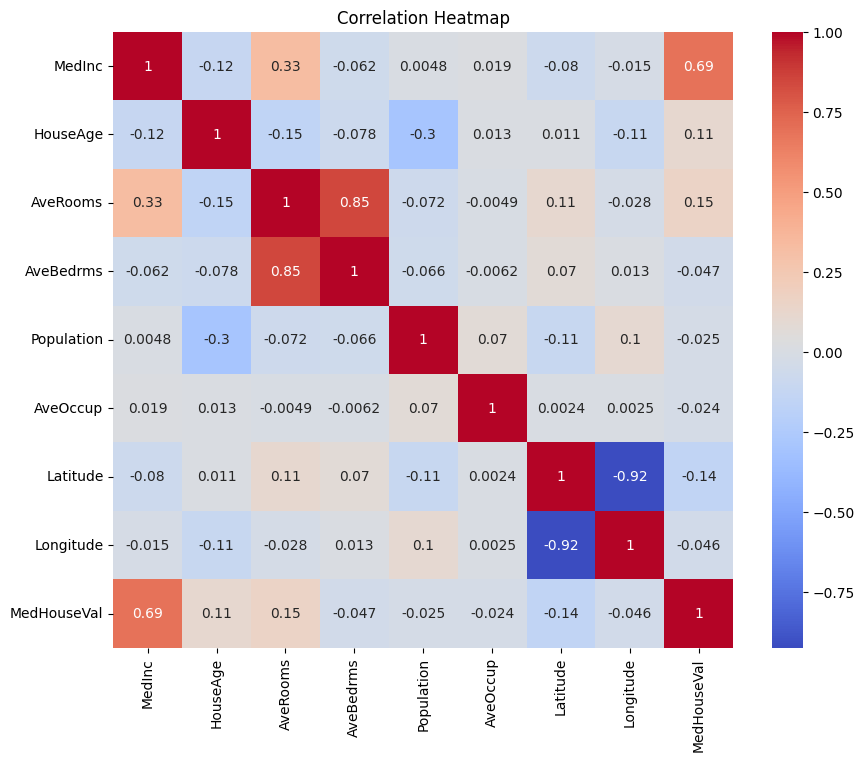

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [10]:
#Feature Engineering

In [12]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [13]:
#Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [15]:
#Linear Regression Model

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

In [17]:
#Evaluate Linear Regression

In [18]:
print("Linear Regression Results")

print("MAE :", mean_absolute_error(y_test, lr_prediction))

print("MSE :", mean_squared_error(y_test, lr_prediction))

print("R2 Score :", r2_score(y_test, lr_prediction))

Linear Regression Results
MAE : 0.5332001304956555
MSE : 0.5558915986952442
R2 Score : 0.575787706032451


In [19]:
#Random Forest Mode

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

In [21]:
#Evaluate Random Forest

In [22]:
print("Random Forest Results")

print("MAE :", mean_absolute_error(y_test, rf_prediction))

print("MSE :", mean_squared_error(y_test, rf_prediction))

print("R2 Score :", r2_score(y_test, rf_prediction))

Random Forest Results
MAE : 0.32773108008720936
MSE : 0.25602182673365537
R2 Score : 0.8046244867176197


In [23]:
#Compare Models

In [24]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "R2 Score":[
        r2_score(y_test, lr_prediction),
        r2_score(y_test, rf_prediction)
    ]

})

results

,Model,R2 Score
0,Linear Regression,0.575788
1,Random Forest,0.804624


In [25]:
#Bar Graph

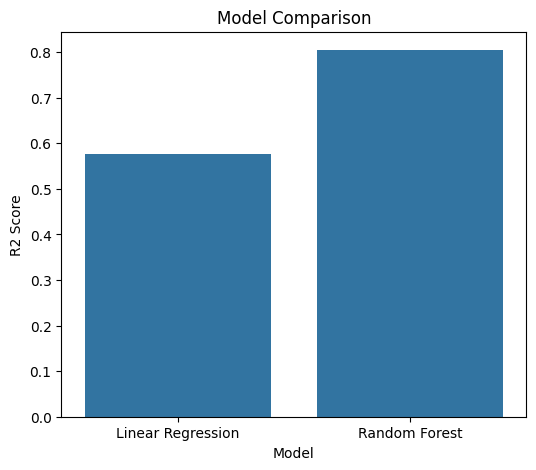

In [26]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison")

plt.show()

In [27]:
#Predict a House Price

In [28]:
sample_house = X.iloc[[0]]

prediction = rf.predict(sample_house)

print("Predicted House Price :", prediction[0])

Predicted House Price : 4.302172900000001


In [29]:
#Save the Model

In [30]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
